# EDA — E-Commerce Fraud Data

Exploratory data analysis for `Fraud_Data.csv`, including IP-to-country geolocation mapping.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print('Fraud_Data shape:', fraud_df.shape)
fraud_df.head()

Fraud_Data shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


## 1. Data Types and Missing Values

In [2]:
fraud_df.info()
print('\nMissing values:')
print(fraud_df.isnull().sum())
print('\nDuplicates:', fraud_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB

Missing values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class      


Duplicates: 0


In [3]:
# Fix datetime columns
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])
fraud_df.dtypes

user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value             int64
device_id                 object
source                    object
browser                   object
sex                       object
age                        int64
ip_address               float64
class                      int64
dtype: object

## 2. Class Imbalance

class
0    136961
1     14151
Name: count, dtype: int64

Fraud rate: 9.36%


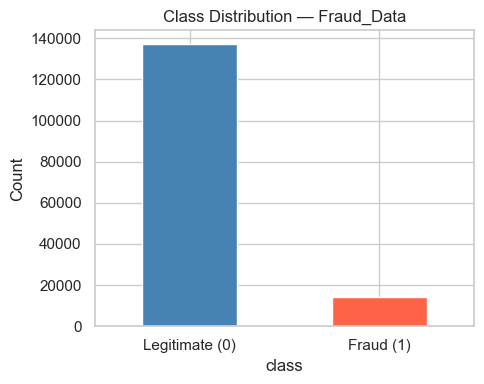

In [4]:
class_counts = fraud_df['class'].value_counts()
print(class_counts)
print(f'\nFraud rate: {class_counts[1] / len(fraud_df) * 100:.2f}%')

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax)
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
ax.set_title('Class Distribution — Fraud_Data')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Univariate Distributions

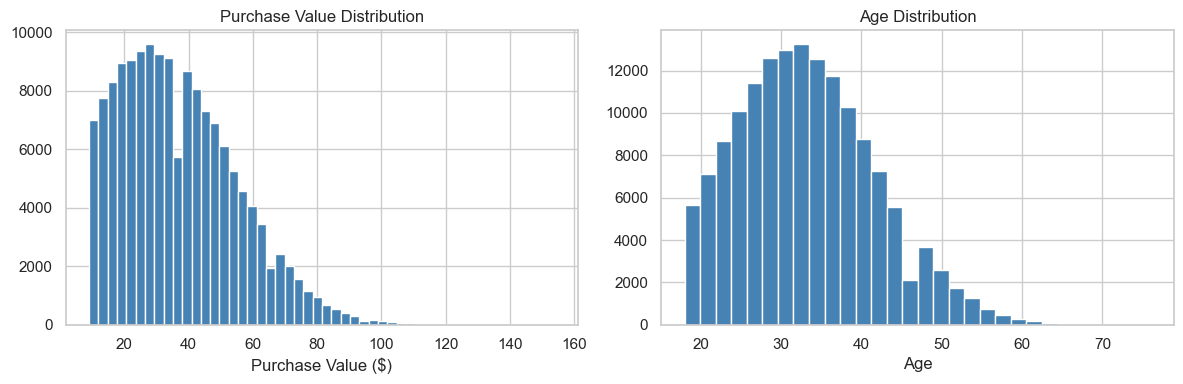


source:
 source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64

browser:
 browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64

sex:
 sex
M    88293
F    62819
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fraud_df['purchase_value'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Purchase Value Distribution')
axes[0].set_xlabel('Purchase Value ($)')

fraud_df['age'].hist(bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
plt.tight_layout()
plt.show()

# Categorical counts
for col in ['source', 'browser', 'sex']:
    print(f'\n{col}:\n', fraud_df[col].value_counts())

## 4. Bivariate Analysis — Fraud Rate by Feature

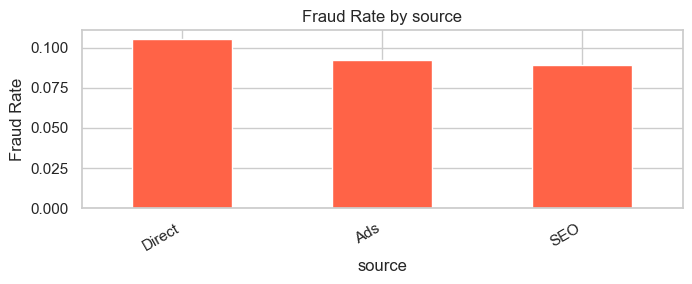

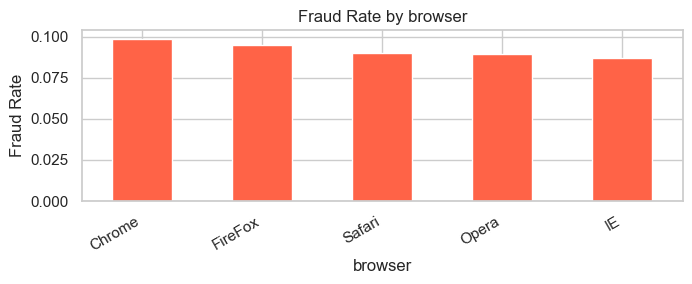

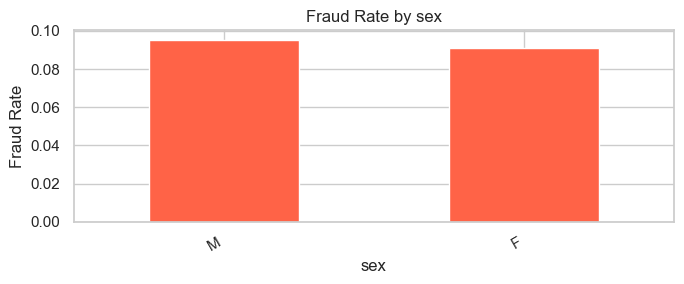

In [6]:
for col in ['source', 'browser', 'sex']:
    fraud_rate = fraud_df.groupby(col)['class'].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 3))
    fraud_rate.plot(kind='bar', ax=ax, color='tomato')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## 5. IP Address → Country Mapping

In [7]:
# Convert IPs to integers for range-based merge
fraud_df['ip_int'] = fraud_df['ip_address'].astype(np.int64)
ip_df['lower_int'] = ip_df['lower_bound_ip_address'].astype(np.int64)
ip_df['upper_int'] = ip_df['upper_bound_ip_address'].astype(np.int64)

# Sort both on the key column for merge_asof
fraud_sorted = fraud_df.sort_values('ip_int').reset_index(drop=False)
ip_sorted = ip_df.sort_values('lower_int')

# Range join: find the row in ip_df where lower_int <= ip_int
merged = pd.merge_asof(
    fraud_sorted,
    ip_sorted[['lower_int', 'upper_int', 'country']],
    left_on='ip_int',
    right_on='lower_int',
    direction='backward'
)

# Keep only valid matches (ip_int must be within the range)
merged['country'] = merged.apply(
    lambda r: r['country'] if pd.notna(r['upper_int']) and r['ip_int'] <= r['upper_int'] else 'Unknown',
    axis=1
)

# Restore original order
fraud_df = merged.sort_values('index').drop(columns=['index', 'lower_int', 'upper_int', 'ip_int']).reset_index(drop=True)

print('Country mapping complete. Unknown:', (fraud_df['country'] == 'Unknown').sum())
fraud_df[['ip_address', 'country']].head(10)

Country mapping complete. Unknown: 21966


,ip_address,country
0,7.327584e+08,Japan
1,3.503114e+08,United States
2,2.621474e+09,United States
3,3.840542e+09,Unknown
4,4.155831e+08,United States
5,2.809315e+09,Canada
6,3.987484e+09,Unknown
7,1.692459e+09,United States
8,3.719094e+09,China
9,3.416747e+08,United States


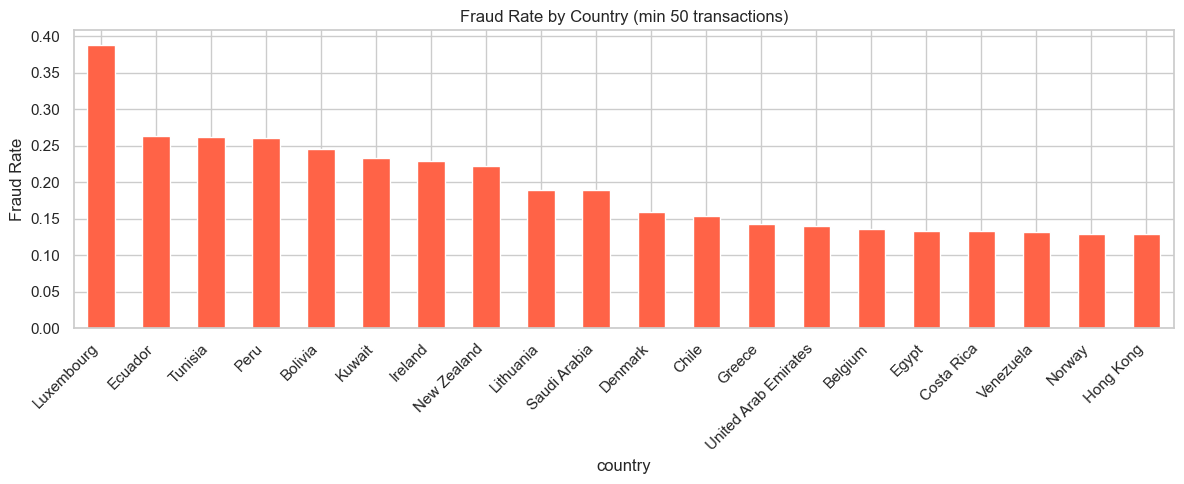

In [8]:
# Fraud rate by top 20 countries
country_stats = fraud_df.groupby('country').agg(
    total=('class', 'count'),
    fraud=('class', 'sum')
).assign(fraud_rate=lambda x: x['fraud'] / x['total'])

top_countries = country_stats[country_stats['total'] > 50].sort_values('fraud_rate', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top_countries['fraud_rate'].plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Fraud Rate by Country (min 50 transactions)')
ax.set_ylabel('Fraud Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [9]:
# Time since signup (hours)
fraud_df['time_since_signup'] = (
    fraud_df['purchase_time'] - fraud_df['signup_time']
).dt.total_seconds() / 3600

# Hour of day and day of week
fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour
fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.dayofweek

# Transaction velocity: count of transactions per user in the 24h before each transaction
fraud_df = fraud_df.sort_values(['user_id', 'purchase_time'])
fraud_df['tx_count_24h'] = (
    fraud_df.groupby('user_id')['purchase_time']
    .transform(lambda s: s.expanding().count() - 1)
)

print('New features added:')
fraud_df[['time_since_signup', 'hour_of_day', 'day_of_week', 'tx_count_24h']].describe()

New features added:


,time_since_signup,hour_of_day,day_of_week,tx_count_24h
count,151112.000000,151112.000000,151112.000000,151112.0
mean,1370.008125,11.521593,3.011819,0.0
std,868.406422,6.912474,2.006203,0.0
min,0.000278,0.000000,0.000000,0.0
25%,607.431528,6.000000,1.000000,0.0
50%,1368.429306,12.000000,3.000000,0.0
75%,2123.479028,17.000000,5.000000,0.0
max,2879.992222,23.000000,6.000000,0.0


C:\Users\maedo\AppData\Local\Temp\ipykernel_17944\1125973155.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_fraud = fraud_df.groupby('signup_bucket')['class'].mean()


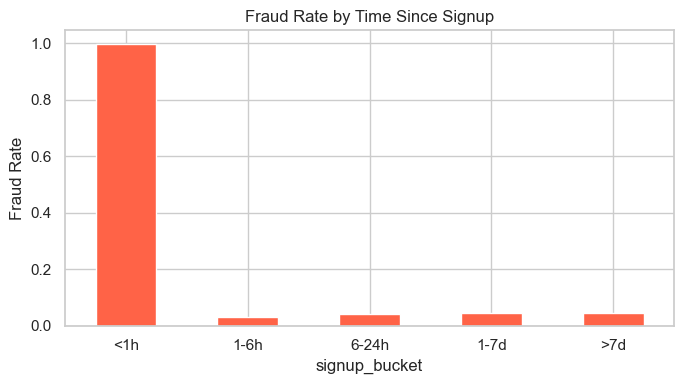

In [10]:
# Fraud rate by time_since_signup bucket
fraud_df['signup_bucket'] = pd.cut(fraud_df['time_since_signup'], bins=[0, 1, 6, 24, 168, np.inf],
                                    labels=['<1h', '1-6h', '6-24h', '1-7d', '>7d'])
bucket_fraud = fraud_df.groupby('signup_bucket')['class'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bucket_fraud.plot(kind='bar', color='tomato', ax=ax)
ax.set_title('Fraud Rate by Time Since Signup')
ax.set_ylabel('Fraud Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 7. Save Cleaned Dataset

In [11]:
fraud_df.drop(columns=['signup_bucket'], inplace=True)
fraud_df.to_csv('../data/processed/fraud_data_clean.csv', index=False)
print('Saved to data/processed/fraud_data_clean.csv')
print('Shape:', fraud_df.shape)

Saved to data/processed/fraud_data_clean.csv
Shape: (151112, 16)
